In [3]:
# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Technical Indicators
import ta

# Save / Load Objects
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)
print("Libraries Imported Successfully!")

TensorFlow Version: 2.20.0
Libraries Imported Successfully!


In [4]:
# ==========================================================
# 2. PROJECT CONFIGURATION
# ==========================================================

# Dataset
DATASET_PATH = "/btc_1d_data_2018_to_2025.csv"   # Change this if your file name is different

# Model Configuration
INPUT_DAYS = 90
OUTPUT_DAYS = 30

# Training Configuration
TEST_SIZE = 0.20
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001
RANDOM_STATE = 42

print("Configuration Loaded Successfully!")

Configuration Loaded Successfully!


In [5]:
# ==========================================================
# 3. LOAD DATASET
# ==========================================================

df = pd.read_csv("/btc_1d_data_2018_to_2025.csv")

print(f"Dataset Shape : {df.shape}")

df.head()

Dataset Shape : (3089, 12)


,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00.000000 UTC,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,1.147997e+08,105595,3961.938946,5.280975e+07,0
1,2018-01-02 00:00:00.000000 UTC,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999000 UTC,2.797171e+08,177728,11346.326739,1.580801e+08,0
2,2018-01-03 00:00:00.000000 UTC,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999000 UTC,2.361169e+08,162787,8994.953566,1.335873e+08,0
3,2018-01-04 00:00:00.000000 UTC,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999000 UTC,3.127816e+08,170310,12680.812951,1.861168e+08,0
4,2018-01-05 00:00:00.000000 UTC,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999000 UTC,3.693220e+08,192969,13346.622293,2.118299e+08,0


In [6]:
# ==========================================================
# 4. DATA CLEANING
# ==========================================================

# Check Dataset Information
print("=" * 50)
print("Dataset Information")
print("=" * 50)
print(df.info())

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Check Duplicate Rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Convert Date Columns to Datetime
df["Open time"] = pd.to_datetime(df["Open time"])
df["Close time"] = pd.to_datetime(df["Close time"])

# Drop Unnecessary Column
df.drop(columns=["Ignore"], inplace=True)

# Sort Dataset by Time
df.sort_values("Open time", inplace=True)

# Reset Index
df.reset_index(drop=True, inplace=True)

print("\n✅ Data Cleaning Completed Successfully!")

print("\nFinal Dataset Shape:", df.shape)

df.head()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3089 entries, 0 to 3088
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Open time                     3089 non-null   object 
 1   Open                          3089 non-null   float64
 2   High                          3089 non-null   float64
 3   Low                           3089 non-null   float64
 4   Close                         3089 non-null   float64
 5   Volume                        3089 non-null   float64
 6   Close time                    3089 non-null   object 
 7   Quote asset volume            3089 non-null   float64
 8   Number of trades              3089 non-null   int64  
 9   Taker buy base asset volume   3089 non-null   float64
 10  Taker buy quote asset volume  3089 non-null   float64
 11  Ignore                        3089 non-null   int64  
dtypes: float64(8), int64(2), object(2)
memory 

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume
0,2018-01-01 00:00:00+00:00,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000+00:00,1.147997e+08,105595,3961.938946,5.280975e+07
1,2018-01-02 00:00:00+00:00,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999000+00:00,2.797171e+08,177728,11346.326739,1.580801e+08
2,2018-01-03 00:00:00+00:00,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999000+00:00,2.361169e+08,162787,8994.953566,1.335873e+08
3,2018-01-04 00:00:00+00:00,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999000+00:00,3.127816e+08,170310,12680.812951,1.861168e+08
4,2018-01-05 00:00:00+00:00,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999000+00:00,3.693220e+08,192969,13346.622293,2.118299e+08


In [7]:
# ==========================================================
# 5. FEATURE ENGINEERING
# ==========================================================

# Moving Averages
df["MA7"] = ta.trend.sma_indicator(df["Close"], window=7)
df["MA30"] = ta.trend.sma_indicator(df["Close"], window=30)

# Exponential Moving Averages
df["EMA20"] = ta.trend.ema_indicator(df["Close"], window=20)
df["EMA50"] = ta.trend.ema_indicator(df["Close"], window=50)

# Relative Strength Index
df["RSI"] = ta.momentum.rsi(df["Close"], window=14)

# MACD
macd = ta.trend.MACD(df["Close"])

df["MACD"] = macd.macd()
df["MACD_Signal"] = macd.macd_signal()
df["MACD_Hist"] = macd.macd_diff()

# Bollinger Bands
bb = ta.volatility.BollingerBands(df["Close"])

df["BB_High"] = bb.bollinger_hband()
df["BB_Low"] = bb.bollinger_lband()
df["BB_Middle"] = bb.bollinger_mavg()

# Average True Range
atr = ta.volatility.AverageTrueRange(
    high=df["High"],
    low=df["Low"],
    close=df["Close"]
)

df["ATR"] = atr.average_true_range()

# Daily Return
df["Daily Return"] = df["Close"].pct_change()

# Rolling Volatility
df["Volatility"] = df["Daily Return"].rolling(window=30).std()

print("✅ Feature Engineering Completed!")

print("\nDataset Shape:", df.shape)

df.tail()

✅ Feature Engineering Completed!

Dataset Shape: (3089, 25)


,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,...,RSI,MACD,MACD_Signal,MACD_Hist,BB_High,BB_Low,BB_Middle,ATR,Daily Return,Volatility
3084,2026-06-12 00:00:00+00:00,63626.00,64394.44,62829.81,63580.01,16397.05240,2026-06-12 23:59:59.999000+00:00,1.042662e+09,3154052,8373.87233,...,32.380806,-3826.791144,-3528.515742,-298.275402,80355.513295,56503.036705,68429.2750,2383.505463,-0.000723,0.023563
3085,2026-06-13 00:00:00+00:00,63580.00,64762.77,63418.66,64458.01,9960.74163,2026-06-13 23:59:59.999000+00:00,6.373021e+08,1489009,5326.34918,...,36.101893,-3576.284750,-3538.069544,-38.215207,79151.679855,56446.175145,67798.9275,2309.262930,0.013809,0.023243
3086,2026-06-14 00:00:00+00:00,64458.01,65800.00,63678.83,65746.45,13203.03375,2026-06-14 23:59:59.999000+00:00,8.536545e+08,2060901,6966.04602,...,41.214306,-3236.482137,-3477.752062,241.269925,77720.138208,56720.160792,67220.1495,2295.827720,0.019989,0.023532
3087,2026-06-15 00:00:00+00:00,65746.45,67292.15,65354.00,66328.74,18559.80102,2026-06-15 23:59:59.999000+00:00,1.230675e+09,3140494,8827.32403,...,43.417632,-2886.921547,-3359.585959,472.664412,76451.651641,57028.520359,66740.0860,2270.279312,0.008857,0.023650
3088,2026-06-16 00:00:00+00:00,66328.74,66463.26,65650.00,66241.66,4220.27610,2026-06-16 23:59:59.999000+00:00,2.788114e+08,648707,2042.73136,...,43.157123,-2587.096451,-3205.088057,617.991606,75374.268293,57285.139707,66329.7040,2166.206504,-0.001313,0.023650


In [8]:
# ==========================================================
# 6. FEATURE SCALING
# ==========================================================

# Remove rows containing NaN values created by technical indicators
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# Features used for training
FEATURE_COLUMNS = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Quote asset volume",
    "Number of trades",
    "Taker buy base asset volume",
    "Taker buy quote asset volume",
    "MA7",
    "MA30",
    "EMA20",
    "EMA50",
    "RSI",
    "MACD",
    "MACD_Signal",
    "MACD_Hist",
    "BB_High",
    "BB_Low",
    "BB_Middle",
    "ATR",
    "Daily Return",
    "Volatility"
]

TARGET_COLUMN = "Close"

# Initialize Scalers
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Scale Features
scaled_features = feature_scaler.fit_transform(df[FEATURE_COLUMNS])

# Scale Target
scaled_target = target_scaler.fit_transform(df[[TARGET_COLUMN]])

print("Feature Shape :", scaled_features.shape)
print("Target Shape  :", scaled_target.shape)

Feature Shape : (3040, 23)
Target Shape  : (3040, 1)


In [12]:
# ==========================================================
# 7. CREATE SEQUENCES & TRAIN-TEST SPLIT
# ==========================================================

# Input and Output Sequences
X = []
y = []

for i in range(len(scaled_features) - INPUT_DAYS - OUTPUT_DAYS):

    # Previous 90 Days
    X.append(
        scaled_features[i:i + INPUT_DAYS]
    )

    # Next 30 Closing Prices
    y.append(
        scaled_target[
            i + INPUT_DAYS :
            i + INPUT_DAYS + OUTPUT_DAYS
        ]
    )

# Convert to NumPy Arrays
X = np.array(X)
y = np.array(y)

# Reshape Target
y = y.reshape(y.shape[0], OUTPUT_DAYS)

# Chronological Train-Test Split
train_size = int(len(X) * (1 - TEST_SIZE))

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("=" * 50)
print("Sequence Creation Completed")
print("=" * 50)

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

Sequence Creation Completed
X_train : (2336, 90, 23)
y_train : (2336, 30)
X_test  : (584, 90, 23)
y_test  : (584, 30)


In [13]:
# ==========================================================
# 8. BUILD, COMPILE & TRAIN LSTM MODEL
# ==========================================================

# Build Model
model = Sequential([

    LSTM(
        units=128,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dropout(0.2),

    LSTM(
        units=64
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(OUTPUT_DAYS)

])

# Compile Model
optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="bitcoin_lstm.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Train Model
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    callbacks=[
        early_stop,
        checkpoint
    ],

    verbose=1

)

print("\nTraining Completed Successfully!")

model.summary()

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0304 - mae: 0.1137
Epoch 1: val_loss improved from None to 0.03719, saving model to bitcoin_lstm.keras

Epoch 1: finished saving model to bitcoin_lstm.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - loss: 0.0155 - mae: 0.0761 - val_loss: 0.0372 - val_mae: 0.1729
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0032 - mae: 0.0395
Epoch 2: val_loss improved from 0.03719 to 0.01617, saving model to bitcoin_lstm.keras

Epoch 2: finished saving model to bitcoin_lstm.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - loss: 0.0029 - mae: 0.0377 - val_loss: 0.0162 - val_mae: 0.1068
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0025 - mae: 0.0339
Epoch 3: val_loss did not improve from 0.01617
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - loss: 0.0025 - mae: 0.0342 - val_loss: 0.0192 - val_mae: 0.1210
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0020 - mae: 0.0310
Epoch 4: val_loss improv

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 128)        │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,908 (1.49 MB)

 Trainable params: 130,302 (508.99 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 260,606 (1018.00 KB)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
MODEL PERFORMANCE
MAE  : 7281.24
RMSE : 9317.03
MAPE : 7.87%


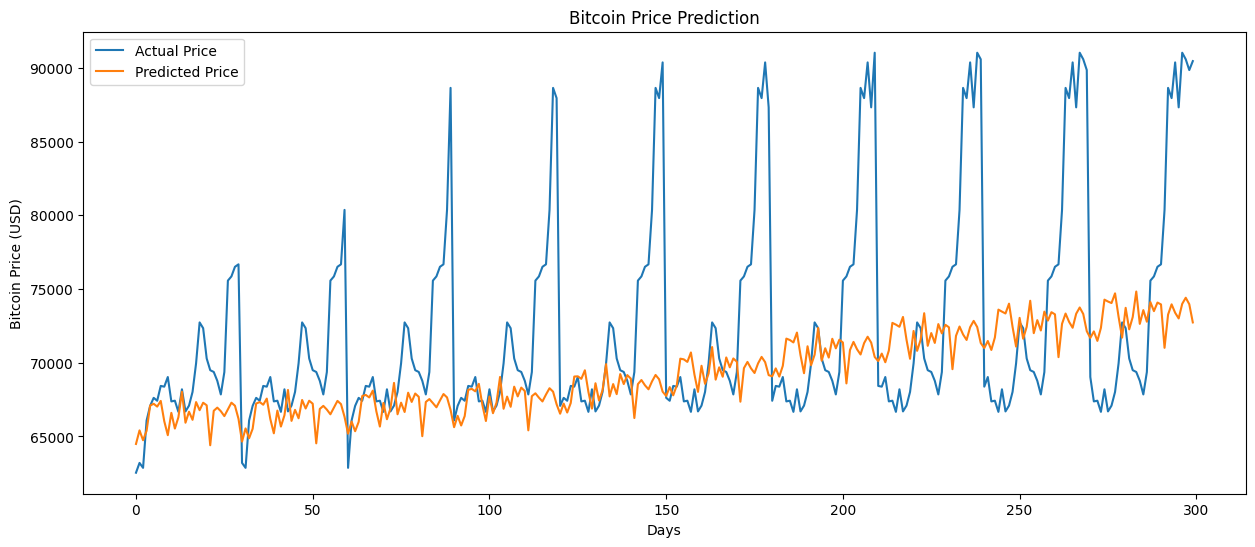

In [14]:
# ==========================================================
# 9. EVALUATE MODEL
# ==========================================================

# Load Best Saved Model
model = load_model("bitcoin_lstm.keras")

# Predict
predictions = model.predict(X_test)

# Convert Back to Original Bitcoin Prices
predictions = target_scaler.inverse_transform(predictions.reshape(-1,1))
actual = target_scaler.inverse_transform(y_test.reshape(-1,1))

# Evaluation Metrics
mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))
mape = mean_absolute_percentage_error(actual, predictions)

print("="*50)
print("MODEL PERFORMANCE")
print("="*50)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape*100:.2f}%")

# Plot
plt.figure(figsize=(15,6))

plt.plot(actual[:300], label="Actual Price")
plt.plot(predictions[:300], label="Predicted Price")

plt.title("Bitcoin Price Prediction")
plt.xlabel("Days")
plt.ylabel("Bitcoin Price (USD)")
plt.legend()

plt.show()

In [15]:
# ==========================================================
# 10. SAVE MODEL & SCALERS
# ==========================================================

# Save Model
model.save("bitcoin_lstm.keras")

# Save Scalers
joblib.dump(feature_scaler, "feature_scaler.pkl")
joblib.dump(target_scaler, "target_scaler.pkl")

print("✅ Model Saved Successfully!")
print("✅ Feature Scaler Saved!")
print("✅ Target Scaler Saved!")

✅ Model Saved Successfully!
✅ Feature Scaler Saved!
✅ Target Scaler Saved!


In [16]:
# ==========================================================
# 11. SAVE PREDICTIONS
# ==========================================================

results = pd.DataFrame({
    "Actual Price": actual.flatten(),
    "Predicted Price": predictions.flatten()
})

results.to_csv("bitcoin_predictions.csv", index=False)

print("✅ Predictions Saved Successfully!")

✅ Predictions Saved Successfully!
